# KLASIFIKASI PENYAKIT JANTUNG DENGAN ALGORITMA RANDOM FOREST



# Pendahuluan dan Paparan Data

Masalah yang akan dibahas pada eksperimen kali ini adalah mengklasifikasikan penyakit jantung dengan menggunakan algoritma Random Forest. Algoritma Random Forest dipilih karena kemampuannya menangani data dengan banyak fitur dan outlier secara efektif, serta memberikan hasil yang stabil melalui teknik ensemble learning. Eksperimen ini bertujuan untuk mengevaluasi model Random Forest dalam klasifikasi penyakit jantung.

## Library

In [108]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Statistik dan sumber dari dataset yang digunakan
Dataset yang digunakan adalah dataset "Heart Disease Prediction Dataset" dari Farhaan Nazirkhan dan Sarwin Rajiah yang bersumber dari situs Kaggle (https://www.kaggle.com/datasets/mfarhaannazirkhan/heart-dataset/data). Dataset tersebut mempunyai 2181 baris dan 14 kolom


In [109]:
# Download latest version
path = kagglehub.dataset_download("mfarhaannazirkhan/heart-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mfarhaannazirkhan/heart-dataset/versions/1


In [110]:
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/datasets/mfarhaannazirkhan/heart-dataset/versions/1/raw_merged_heart_dataset.csv
/root/.cache/kagglehub/datasets/mfarhaannazirkhan/heart-dataset/versions/1/cleaned_merged_heart_dataset.csv


In [111]:
path = '/root/.cache/kagglehub/datasets/mfarhaannazirkhan/heart-dataset/versions/1/raw_merged_heart_dataset.csv'
df = pd.read_csv(path)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Deskripsi Kolom


1.   age: Age of the patient (Numeric).
2.   sex: Gender of the patient. Values: 1 = male, 0 = female.
1.   cp: Chest pain type. Values: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic.
2.   trestbps: Resting Blood Pressure (in mm Hg) (Numeric).
1.   chol: Serum Cholesterol level (in mg/dl) (Numeric).
2.   fbs: Fasting blood sugar > 120 mg/dl. Values: 1 = true, 0 = false.
1.   restecg: Resting electrocardiographic results. Values: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy.
2.   thalach: Maximum heart rate achieved (Numeric).
1.   exang: Exercise-induced angina. Values: 1 = yes, 0 = no.
1.   oldpeak: ST depression induced by exercise relative to rest (Numeric).
2.   slope: Slope of the peak exercise ST segment. Values: 0 = Upsloping, 1 = Flat, 2 = Downsloping.
2.   ca: Number of major vessels (0-3) colored by fluoroscopy. Values: 0, 1, 2, 3.
1.   thal: Thalassemia types. Values: 1 = Normal, 2 = Fixed defect, 3 = Reversible defect.
2.   target: Outcome variable (heart attack risk). Values: 1 = more chance of heart attack, 0 = less chance of heart attack.























In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   object 
 4   chol      2181 non-null   object 
 5   fbs       2181 non-null   object 
 6   restecg   2181 non-null   object 
 7   thalachh  2181 non-null   object 
 8   exang     2181 non-null   object 
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   object 
 11  ca        2181 non-null   object 
 12  thal      2181 non-null   object 
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 238.7+ KB


In [113]:
# Statistik Numerik
df.describe()

,age,sex,cp,oldpeak,target
count,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000
mean,53.477762,0.693260,1.507565,0.990509,0.496103
std,9.194787,0.461246,1.371587,1.141851,0.500099
min,28.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,2.000000,0.600000,0.000000
75%,60.000000,1.000000,2.000000,1.600000,1.000000
max,77.000000,1.000000,4.000000,6.200000,1.000000


In [114]:
# Statistik Object
object_columns = df.select_dtypes(include=['object']).columns

for col in object_columns:
    print(f"Distribusi nilai untuk kolom '{col}':")
    print(df[col].value_counts(), "\n")

Distribusi nilai untuk kolom 'trestbps':
trestbps
120    300
130    278
140    249
110    139
150    129
160     89
138     81
125     78
128     72
112     60
132     51
118     47
135     43
108     40
124     38
145     37
100     32
134     31
152     30
170     29
122     27
180     25
136     21
115     20
126     19
142     19
105     19
146     13
94      13
178     13
102     12
148     11
144     10
200      8
155      7
106      7
123      7
117      7
165      7
154      6
192      6
174      6
101      6
156      6
129      6
104      6
172      6
114      5
164      4
98       1
190      1
?        1
113      1
92       1
158      1
Name: count, dtype: int64 

Distribusi nilai untuk kolom 'chol':
chol
234    40
204    38
254    34
197    34
212    32
       ..
171     1
365     1
344     1
85      1
393     1
Name: count, Length: 202, dtype: int64 

Distribusi nilai untuk kolom 'fbs':
fbs
0    1873
1     300
?       8
Name: count, dtype: int64 

Distribusi nilai untuk kol

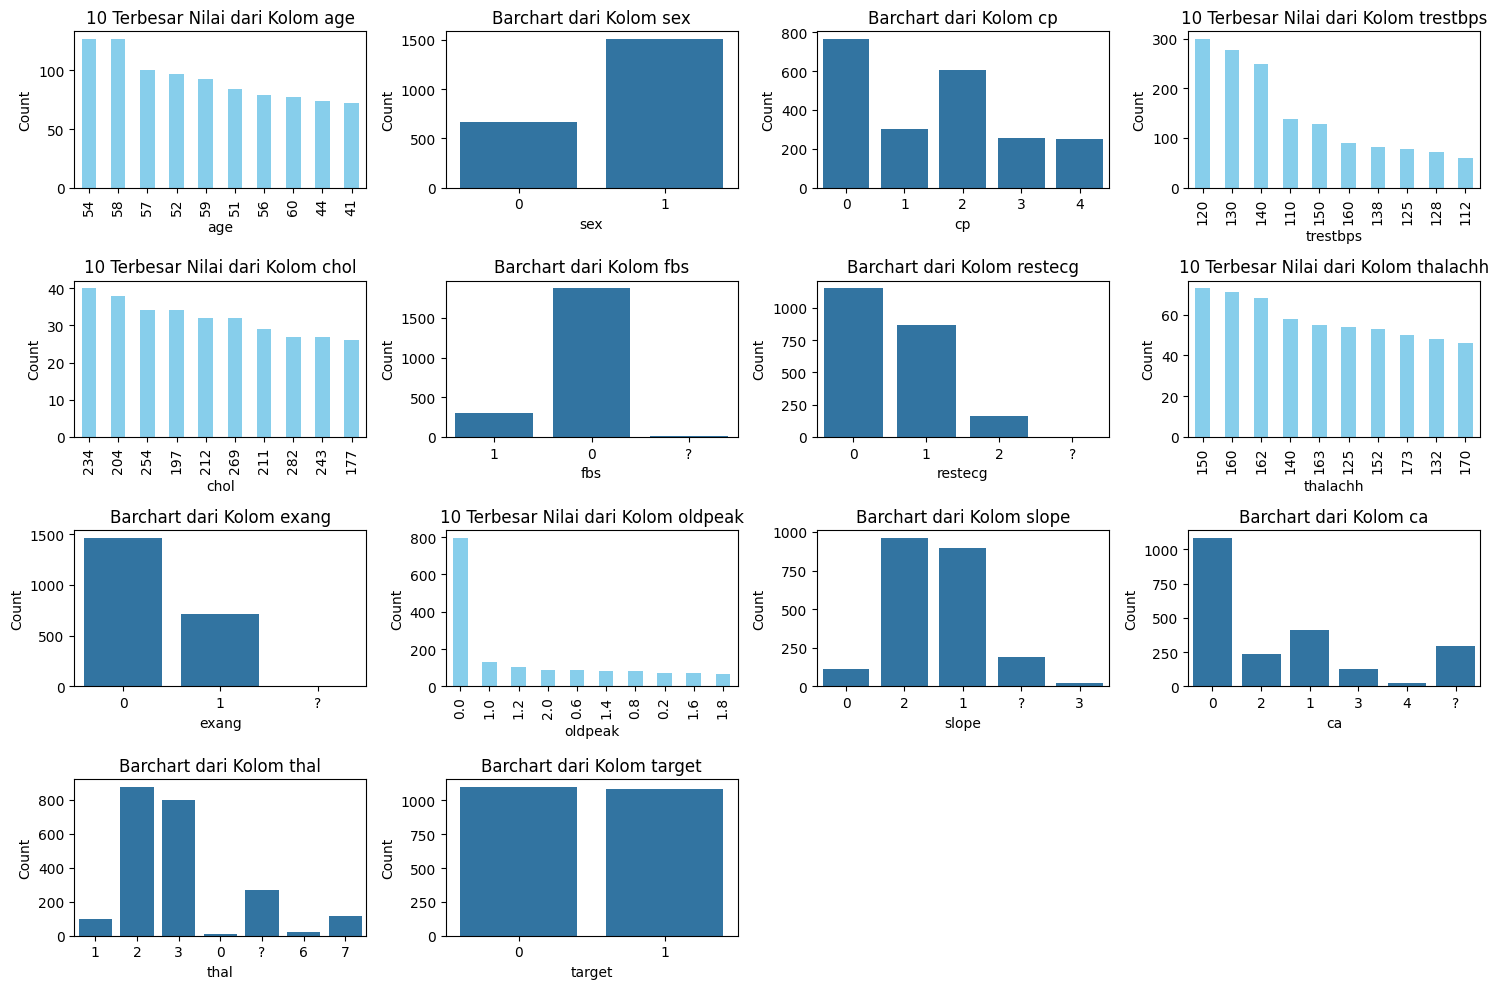

In [115]:
# Visualisasi fitur
plt.figure(figsize=(15, 10))

for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    if df[col].nunique() < 20: # Fitur dengan nilai unik < 20
        sns.countplot(x=df[col])
        plt.title(f'Barchart dari Kolom {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    else:  # Fitur dengan nilai unik tinggi
        df[col].value_counts().head(10).plot(kind='bar', color='skyblue')
        plt.title(f'10 Terbesar Nilai dari Kolom {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

plt.tight_layout()
plt.show()

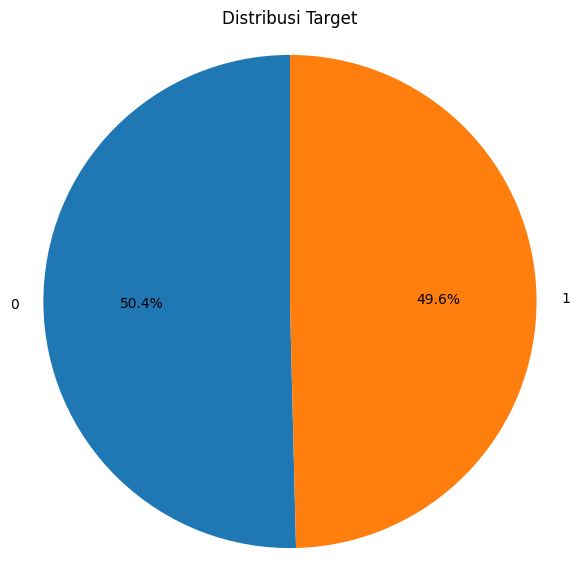

In [116]:
# Visualisasi persebaran data target
target_counts = df['target'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Target')
plt.axis('equal')
plt.show()

Berdasarkan pie chart distribusi target, terlihat bahwa proporsi kelas dalam dataset ini cukup seimbang, dengan sekitar 50.4% untuk kelas "0" dan 49.6% untuk kelas "1". Perbedaan proporsi ini sangat kecil, sehingga tidak memerlukan penanganan ketidakseimbangan (imbalance handling).

## Preprocessing Dataset
Tahapan preprocessing dataset dilakukan dengan pengecekan missing value (jika ada maka dilakukan penanganan missing value), pengubahan tipe data ke numerik, pengecekan outlier (untuk model RF tidak perlu dilakukan penanganan outlier), cek duplikasi data, dan seleksi fitur.

### Check missing value

In [117]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exang,0
oldpeak,0


Dalam hal ini, penanganan missing value atau nilai yang hilang tidak perlu dilakukan karena tidak terdapat nilai yang hilang

### Ubah fitur object ke numerik

In [118]:
# Mengubah semua kolom ke tipe numerik
df_clean = df.apply(pd.to_numeric, errors='coerce')
df_clean.fillna(0, inplace=True)

for col in df_clean.columns:
    if col != 'oldpeak':  # Mengecualikan kolom 'oldpeak' (karena bertipe float64)
        df_clean[col] = df_clean[col].astype('int64')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   int64  
 4   chol      2181 non-null   int64  
 5   fbs       2181 non-null   int64  
 6   restecg   2181 non-null   int64  
 7   thalachh  2181 non-null   int64  
 8   exang     2181 non-null   int64  
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   int64  
 11  ca        2181 non-null   int64  
 12  thal      2181 non-null   int64  
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 238.7 KB


### Penghapusan data duplikat

In [119]:
# Memeriksa duplikasi
duplikasi = df_clean.duplicated()

duplikat = df_clean[duplikasi]
print("Data yang duplikat:")
print(duplikat)

jumlah_duplikat = duplikasi.sum()
print(f"Jumlah duplikasi: {jumlah_duplikat}")

Data yang duplikat:
      age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
164    38    1   2       138   175    0        1       173      0      0.0   
303    52    1   0       125   212    0        1       168      0      1.0   
304    53    1   0       140   203    1        0       155      1      3.1   
305    70    1   0       145   174    0        1       125      1      2.6   
306    61    1   0       148   203    0        1       161      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...       ...    ...      ...   
2172   42    1   0       136   315    0        1       125      1      1.8   
2174   59    1   2       126   218    1        1       134      0      2.2   
2175   40    1   0       152   223    0        1       181      0      0.0   
2177   46    1   0       140   311    0        1       120      1      1.8   
2178   59    1   3       134   204    0        1       162      0      0.8   

      slope  ca  thal  target  
164       2

In [120]:
df_clean_with_drop_duplikat = df_clean.drop_duplicates()

### Seleksi Fitur

In [121]:
# seleksi fitur dengan Random Forest
X = df_clean.drop('target', axis=1)
y = df_clean['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

     Feature  Importance
12      thal    0.145802
2         cp    0.121808
10     slope    0.119024
7   thalachh    0.108584
4       chol    0.089556
0        age    0.085673
9    oldpeak    0.081355
3   trestbps    0.075375
11        ca    0.068695
6    restecg    0.037123
1        sex    0.027861
8      exang    0.026375
5        fbs    0.012770


Menurut seleksi fitur yang dapat digunakan adalah 'thal', 'cp', 'slope', 'thalachh', 'chol', 'age', 'oldpeak', 'trestbps', 'ca' karena nilainya cukup memiliki nilai yang besar

### Check outlier

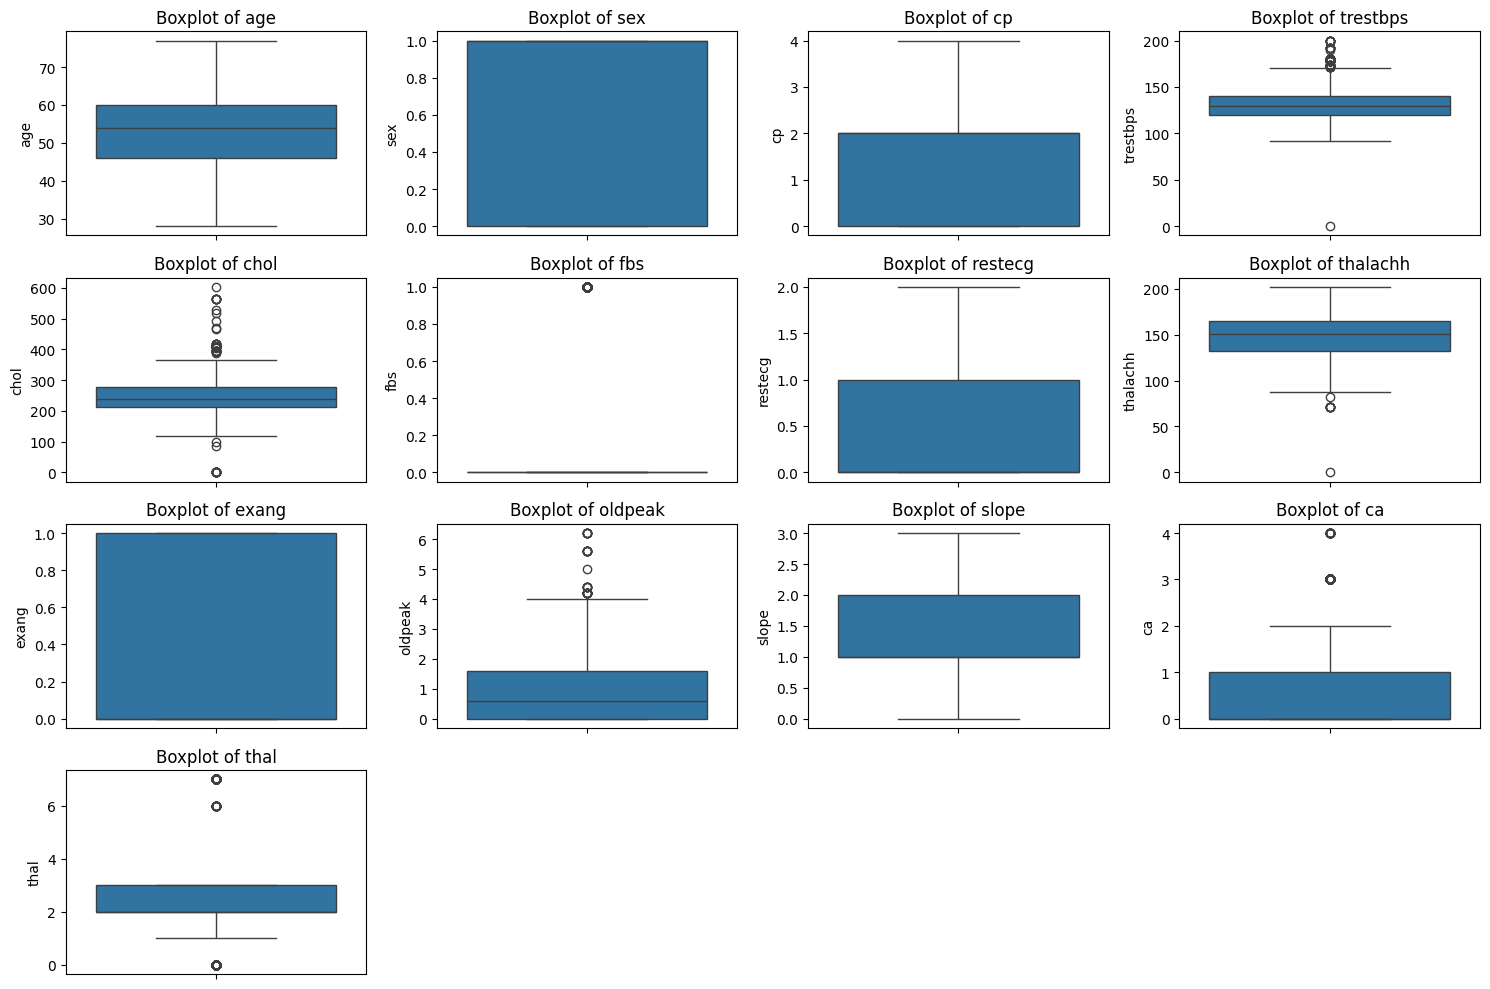

In [122]:
columns_to_boxplot = [col for col in df_clean.columns if col != 'target']
plt.figure(figsize=(15, 10))

for i, col in enumerate(columns_to_boxplot, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Dalam hal ini, penanganan outlier atau pencilan tidak dilakukan karena untuk model Random Forest cukup tahan terhadap outlier atau pencilan

## Pembagian training dan testing
Pembagian data latih (training) dan data uji (testing) dilakukan dengan 80:20 dimana 80% untuk data latih (melatih model) dan 20% untuk data uji (menguji performa model). Tujuan pembagian ini salah satunya adalah untuk menghindari overfitting. Kemudian untuk pembagian X (data fitur) dan y (data target) adalah X untuk semua data kecuali kolom 'target' dan y hanya kolom 'target'.

In [123]:
# skenario data asli
X = df_clean.drop('target', axis=1)
y = df_clean['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Metode dan Eksperimen
Metode yang digunakan dalam eksperimen kali ini adalah Random Forest
Random Forest adalah algoritma pembelajaran berbasis pohon yang sangat efektif dalam Machine Learning. Algoritma ini menghasilkan banyak Pohon Keputusan selama proses pelatihan. Setiap pohon dibangun dengan menggunakan subset data yang dipilih secara acak, serta subset acak dari fitur-fitur pada setiap pembagian data. Pendekatan acak ini menciptakan variasi antar pohon, yang membantu mengurangi kemungkinan overfitting dan meningkatkan akurasi prediksi secara keseluruhan.
Source : https://www.geeksforgeeks.org/random-forest-algorithm-in-machine-learning/


Pengukuran kinerja yang digunakan adalah metrik evaluasi sebagai berikut.
1.   Accuracy sebagai pengukur proporsi prediksi yang benar dibandingkan dengan seluruh prediksi.
$$
\text{Accuracy} = \frac{\text{True Positive} + \text{True Negative}}{\text{Total Observasi}}
$$


2.   Precision sebagai pengukur proporsi prediksi positif yang benar-benar positif (akurasi dalam prediksi kelas positif).
$$
\text{Precision} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Positive}}
$$


1.   Recall sebagai pengukur kemampuan model dalam mendeteksi semua instance dari kelas positif.
$$
\text{Recall} = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}}
$$


2.   F1-Score sebagai pengukur rata-rata harmonis antara Precision dan Recall.
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


Setting parameter yang digunakan adalah


1.   n_estimators untuk menentukan jumlah pohon keputusan (Decision Tree) yang akan dibuat di dalam Random Forest. Dalam eksperimen ini digunakan percobaan n_estimator bernilai 5, 10, 20, 50, dan 100.
1.   max_depth untuk menentukan kedalaman maksimum setiap pohon keputusan. Dalam eksperimen ini digunakan percobaan max_depth bernilai 2, 3, 4, 5, 10, dan None.
2.   max_features untuk menentukan jumlah maksimum fitur yang dipilih secara acak untuk dipertimbangkan di setiap pembagian dalam pohon keputusan. Dalam eksperimen ini digunakan 1 dan 2.
2.   random_state bernilai 42 untuk menentukan seed untuk pengacakan dalam pemilihan sampel bootstrap yang akan memberikan hasil yang konsisten di antara run yang berbeda.


Percobaan dilakukan dengan data asli (tanpa penghapusan duplikasi data dan tanpa seleksi fitur), data dengan penghapusan duplikasi data, data dengan fitur seleksi, data dengan fitur seleksi dan penghapusan duplikasi data.








In [124]:
class RandomForest:
  # fungsi konstruktor untuk menginisialisasi random forest dengan parameter n_estimators, max_depth, max_features, dan random_state
  def __init__(self, n_estimators=10, max_depth=None, max_features=1, random_state=42):
    self.n_estimators = n_estimators
    self.max_depth = max_depth
    self.max_features = max_features
    self.trees = []

  # fungsi untuk melatih model random forest dengan X dan y
  def fit(self, X, y):
    n_samples, n_features = X.shape
    for _ in range(self.n_estimators):
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        if isinstance(X, pd.DataFrame):
            X_sample = X.iloc[idxs].values
            y_sample = y.iloc[idxs].values
        else:
            X_sample = X[idxs]
            y_sample = y[idxs]

        tree = DecisionTreeClassifier(
            max_depth=self.max_depth,
            max_features=self.max_features
        )
        tree.fit(X_sample, y_sample)
        self.trees.append(tree)

  # fungsi untuk melakukan prediksi menggunakan Random Forest
  def predict(self, X):
    if isinstance(X, pd.DataFrame):
        X = X.values
    tree_preds = np.array([tree.predict(X) for tree in self.trees])
    return np.round(np.mean(tree_preds, axis=0))

In [125]:
# Random Forest Tunner
class RandomForestTuner:
    def __init__(self, param_grid):
        self.param_grid = param_grid
        self.best_params_ = None
        self.best_metrics_ = {}
        self.best_score_ = -np.inf
        self.results_ = []

    def fit(self, X, y):
        best_params = None
        best_score = -np.inf
        best_metrics = {}
        for n_estimators in self.param_grid['n_estimators']:
            for max_depth in self.param_grid['max_depth']:
                for max_features in self.param_grid['max_features']:
                    # latih model random forest
                    model = RandomForest(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        max_features=max_features,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_val)

                    # kalkukasi metrik evaluasi
                    accuracy = accuracy_score(y_val, y_pred)
                    precision = precision_score(y_val, y_pred)
                    recall = recall_score(y_val, y_pred)
                    f1 = f1_score(y_val, y_pred)

                    # simpan hasil pada variabel metrics
                    metrics = {
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "max_features": max_features,
                        "accuracy": accuracy,
                        "precision": precision,
                        "recall": recall,
                        "f1": f1,
                    }
                    self.results_.append(metrics)

                    # mencari parameter terbaik berdasarkan accuracy
                    if accuracy > best_score:
                        best_score = f1
                        best_params = {
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'max_features': max_features,
                        }
                        best_metrics = metrics

        self.best_params_ = best_params
        self.best_metrics_ = best_metrics
        self.best_score_ = best_score

        # semua hasil
        results_df = pd.DataFrame(self.results_)

        # parameter dan metrik terbaik
        print("Parameter Terbaik:", self.best_params_)
        print("Metrik Evaluasi Terbaik:", self.best_metrics_)

# Hasil dan Analisis

## Kinerja dan Analisis Tahap Training

### Skenario Data Asli
- **Parameter terbaik:** {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
- **Akurasi:** 0.9657
- **Metrik Evaluasi Lainnya:**
  - Precision: 0.9596
  - Recall: 0.9727
  - F1-Score: 0.9661
- **Confusion Matrix:** [[208, 9], [7, 213]]

- **Analisis:**
  - Model dengan data asli menunjukkan performa terbaik pada tahap training.
  - Tingkat kesalahan sangat rendah, ditunjukkan oleh hanya 16 salah prediksi (9 kelas "1" diprediksi sebagai "0" dan 7 kelas "0" diprediksi sebagai "1").

---

### Skenario Data Tanpa Duplikasi
- **Parameter terbaik:** {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
- **Akurasi:** 0.8259
- **Metrik Evaluasi Lainnya:**
- Precision: 0.7976
- Recall: 0.7528
- F1-Score: 0.7746
- **Analisis:**
  - Penghapusan data duplikasi mengurangi performa model, karena kemungkinan hilangnya pola yang relevan.
  - Data tanpa duplikasi menghasilkan model yang lebih generalisasi, namun lebih lemah dalam mengenali pola yang kompleks pada tahap training.

---

### Skenario Seleksi Fitur
- **Parameter terbaik:** {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
- **Akurasi:** 0.9487
- **Metrik Evaluasi Lainnya:**
- Precision: 0.9654
- Recall: 0.9296
- F1-Score: 0.9472
- **Analisis:**
  - Seleksi fitur mengurangi kompleksitas model tanpa mengorbankan banyak performa, sehingga memberikan hasil yang hampir mendekati data asli.
  - Model lebih fokus pada fitur penting, mengurangi risiko overfitting.

---

### Skenario Tanpa Duplikasi dan Seleksi Fitur
- **Parameter terbaik:** {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
- **Akurasi:** 0.7813
- **Metrik Evaluasi Lainnya:**
- Precision: 0.7667
- Recall: 0.7113
- F1-Score: 0.7380
- **Analisis:**
  - Kombinasi penghapusan duplikasi dan seleksi fitur secara signifikan menurunkan performa model.
  - Meskipun lebih sederhana, model kehilangan terlalu banyak informasi penting untuk mencapai performa optimal.











In [126]:
# hyperparameter grid
param_grid = {
    "n_estimators": [5, 10, 20, 50, 100],
    "max_depth": [2, 3, 4, 5, 10, None],
    "max_features": [1, 2],
}

# tuning
tuner1 = RandomForestTuner(param_grid=param_grid)
tuner1.fit(X, y)

Parameter Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
Metrik Evaluasi Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2, 'accuracy': 0.965675057208238, 'precision': 0.9596412556053812, 'recall': 0.9727272727272728, 'f1': 0.9661399548532731}


Parameter Terbaik:
  n_estimators: 100
  max_depth: None
  max_features: 2


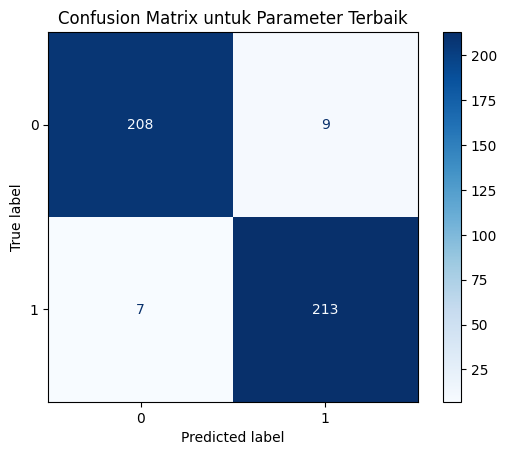

In [127]:
# confusion matrics
print("Parameter Terbaik:")
for param, value in tuner1.best_params_.items():
    print(f"  {param}: {value}")

best_model = RandomForest(
    n_estimators=tuner1.best_params_['n_estimators'],
    max_depth=tuner1.best_params_['max_depth'],
    max_features=tuner1.best_params_['max_features'],
    random_state=42
)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)
cm = confusion_matrix(y_val, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix untuk Parameter Terbaik")
plt.show()

In [128]:
# menampilkan semua hasil
results_df = pd.DataFrame(tuner1.results_)
results_df

,n_estimators,max_depth,max_features,accuracy,precision,recall,f1
0,5,2.0,1,0.679634,0.658730,0.754545,0.703390
1,5,2.0,2,0.743707,0.721311,0.800000,0.758621
2,5,3.0,1,0.757437,0.790816,0.704545,0.745192
3,5,3.0,2,0.718535,0.683019,0.822727,0.746392
4,5,4.0,1,0.768879,0.811518,0.704545,0.754258
5,5,4.0,2,0.796339,0.813397,0.772727,0.792541
6,5,5.0,1,0.771167,0.788462,0.745455,0.766355
7,5,5.0,2,0.800915,0.792952,0.818182,0.805369
8,5,10.0,1,0.919908,0.896996,0.950000,0.922737
9,5,10.0,2,0.933638,0.909871,0.963636,0.935982


## Percobaan Lainnya

In [129]:
# skenario dengan penghapusan data duplikat
X_no_duplicates = df_clean_with_drop_duplikat.drop('target', axis=1)
y_no_duplicates = df_clean_with_drop_duplikat['target']
X_train, X_val, y_train, y_val = train_test_split(X_no_duplicates, y_no_duplicates)

print("Skenario Data Tanpa Duplikasi")
tuner2 = RandomForestTuner(param_grid=param_grid)
tuner2.fit(X_train, y_train)

Skenario Data Tanpa Duplikasi
Parameter Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
Metrik Evaluasi Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2, 'accuracy': 0.8258928571428571, 'precision': 0.7976190476190477, 'recall': 0.7528089887640449, 'f1': 0.7745664739884393}


In [130]:
# skenario dengan seleksi fitur
selected_features = ['thal', 'cp', 'slope', 'thalachh', 'chol', 'age', 'oldpeak', 'trestbps', 'ca', 'target']
X_selected = df_clean[selected_features].drop('target', axis=1)
y_selected = df_clean['target']
X_train, X_val, y_train, y_val = train_test_split(X_selected, y_selected)

print("Skenario Data dengan Seleksi Fitur")
tuner3 = RandomForestTuner(param_grid=param_grid)
tuner3.fit(X_train, y_train)

Skenario Data dengan Seleksi Fitur
Parameter Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
Metrik Evaluasi Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2, 'accuracy': 0.9487179487179487, 'precision': 0.9653846153846154, 'recall': 0.9296296296296296, 'f1': 0.9471698113207547}


In [131]:
# skenario dengan penghapusan data duplikat dan seleksi fitur
df_no_duplicates_selected = df_clean_with_drop_duplikat[selected_features]
X_no_duplicates_selected = df_no_duplicates_selected.drop('target', axis=1)
y_no_duplicates_selected = df_no_duplicates_selected['target']
X_train, X_val, y_train, y_val = train_test_split(X_no_duplicates_selected, y_no_duplicates_selected)

print("Skenario Data Tanpa Duplikasi dan dengan Seleksi Fitur")
tuner4 = RandomForestTuner(param_grid=param_grid)
tuner4.fit(X_train, y_train)

Skenario Data Tanpa Duplikasi dan dengan Seleksi Fitur
Parameter Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
Metrik Evaluasi Terbaik: {'n_estimators': 100, 'max_depth': None, 'max_features': 2, 'accuracy': 0.78125, 'precision': 0.7666666666666667, 'recall': 0.711340206185567, 'f1': 0.7379679144385026}


# Kesimpulan

Berdasarkan percobaan yang dilakukan dengan empat skenario berbeda (data asli, data tanpa duplikasi, data dengan seleksi fitur, dan data tanpa duplikasi serta seleksi fitur), berikut adalah hasil dan kesimpulannya:

1. **Kinerja Terbaik**:
   - Kinerja terbaik dicapai pada **skenario data asli** dengan parameter:
     {'n_estimators': 100, 'max_depth': None, 'max_features': 2}
   - **Metrik Evaluasi**:
     - Akurasi: 0.9657
     - Precision: 0.9596
     - Recall: 0.9727
     - F1-Score: 0.9661
   - **Analisis**:
     - Model menunjukkan kemampuan yang sangat baik dalam mengenali pola dari data asli tanpa perubahan, dengan tingkat kesalahan prediksi yang sangat rendah.

2. **Pengaruh Penghapusan Duplikasi**:
   - Menghapus data duplikasi menurunkan akurasi menjadi **0.8259**.
   - Meskipun penghapusan duplikasi meningkatkan generalisasi model, hasilnya menunjukkan hilangnya beberapa pola penting yang memengaruhi performa keseluruhan.

3. **Pengaruh Seleksi Fitur**:
   - Seleksi fitur menghasilkan akurasi sebesar **0.9487**, dengan penurunan yang tidak signifikan dibandingkan data asli.
   - Model menjadi lebih sederhana dan fokus pada fitur yang paling penting, seperti thal, cp, dan slope, sehingga mengurangi risiko overfitting tanpa kehilangan terlalu banyak performa.

4. **Kombinasi Penghapusan Duplikasi dan Seleksi Fitur**:
   - Kombinasi ini menghasilkan akurasi terendah sebesar **0.7813**.
   - Hilangnya data duplikasi dan fitur tertentu secara bersamaan menyebabkan informasi penting tidak tersedia untuk model, yang mengakibatkan penurunan performa secara signifikan.



Kesimpulan Umum pada Metrik Evaluasi Terbaik:
1. **Pemilihan Model**
: Algoritma Random Forest dipilih karena kemampuannya yang handal dalam menangani data dengan fitur yang kompleks dan saling berinteraksi, serta memberikan stabilitas terhadap overfitting.

2. **Confusion Matrix**
: Model mampu memprediksi mayoritas kasus dengan benar, baik untuk pasien dengan risiko penyakit jantung (label 1) maupun pasien sehat (label 0). Tingkat kesalahan prediksi (false positive dan false negative) sangat rendah.

3. **Analisis Keseluruhan**
: Model ini memiliki tingkat presisi tinggi, sehingga sangat cocok untuk aplikasi di mana kesalahan diagnosis positif (false positive) harus diminimalkan, seperti dalam analisis risiko penyakit jantung. Tingkat recall yang tinggi memastikan bahwa sebagian besar pasien yang berisiko tinggi teridentifikasi dengan benar.
